In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm
import yt
import os
from dotenv import dotenv_values
import glob
import pandas as pd
import re
import matplotlib.cm as cm

In [212]:
# raw_dir = f"snapshots_Nx{Nx}_Ny{Ny}_seed{SEED}_mgs{MAX_GRID_SIZE}_dt{FIXED_DT}_visc_coef{VISC_COEF}_noise_off_step{NOISE_OFF_STEP}_depth{CELL_DEPTH}"
# run_dir = raw_dir.replace('.', 'p')
# plt_dir = os.path.join(run_dir, "plt")

run_dir = "SF_32_1em4_cell_depth_1em5_limiter_false_ts_false_seed_1"
plt_dir = os.path.join(run_dir, "plt_SF_mag0*")
plotfile_paths = sorted(glob.glob(plt_dir))
# plotfile_paths = sorted(glob.glob("plt_SF_mag0*"))

print(f"Found {len(plotfile_paths)} plotfiles in {run_dir}.")

ts = yt.DatasetSeries(plotfile_paths)

first_ds = ts[0]
print("\nAvailable variables in the plotfiles:")
for field in first_ds.field_list:
    print(f" - {field[1]}") 

Found 58 plotfiles in SF_32_1em4_cell_depth_1em5_limiter_false_ts_false_seed_1.

Available variables in the plotfiles:
 - struct_fact_velx_velx
 - struct_fact_velx_vely
 - struct_fact_vely_vely


In [224]:
run_dir_2 = "SF_32_1em4_cell_depth_1em5_limiter_false_ts_false_seed_2"
plt_dir_2 = os.path.join(run_dir_2, "plt_SF_mag0*")
plotfile_paths_2 = sorted(glob.glob(plt_dir_2))
ts_2 = yt.DatasetSeries(plotfile_paths_2)

run_dir_3 = "SF_32_1em4_cell_depth_1em5_limiter_false_ts_false_seed_3"
plt_dir_3 = os.path.join(run_dir_3, "plt_SF_mag0*")
plotfile_paths_3 = sorted(glob.glob(plt_dir_3))
ts_3 = yt.DatasetSeries(plotfile_paths_3)
print(f"Found {len(plotfile_paths_3)} plotfiles in {plt_dir_3}.")

Found 0 plotfiles in SF_32_1em4_cell_depth_1em5_limiter_false_ts_false_seed_3/plt_SF_mag0*.


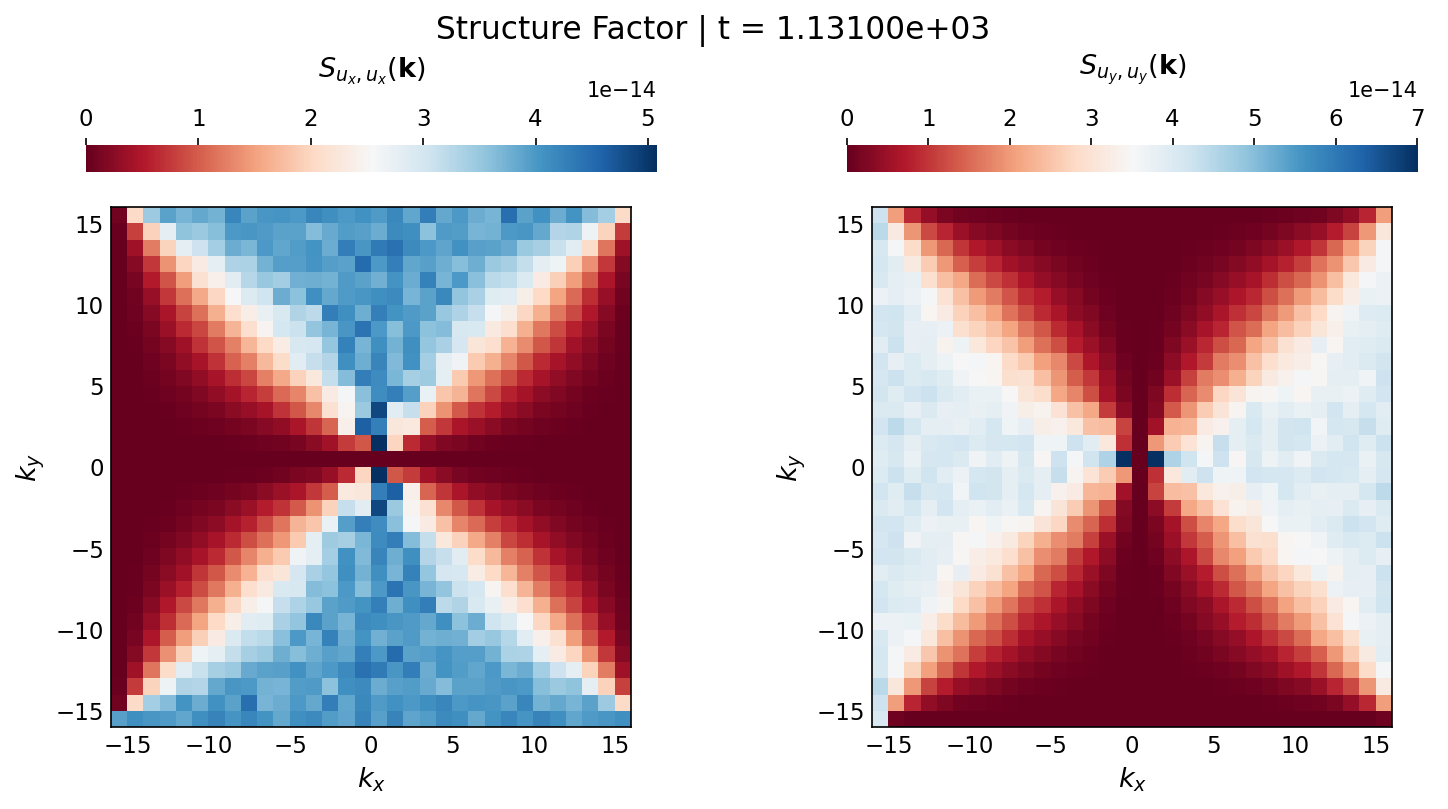

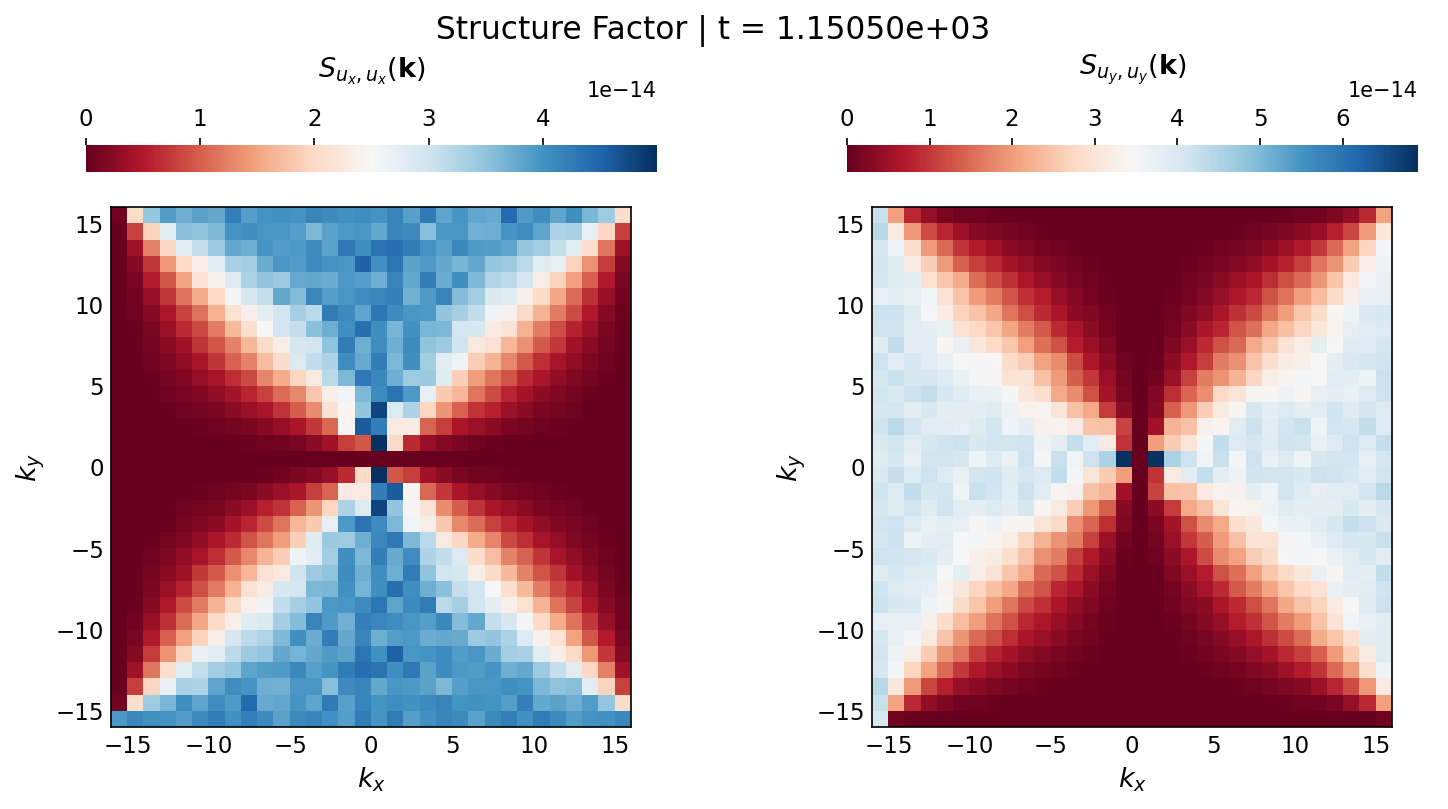

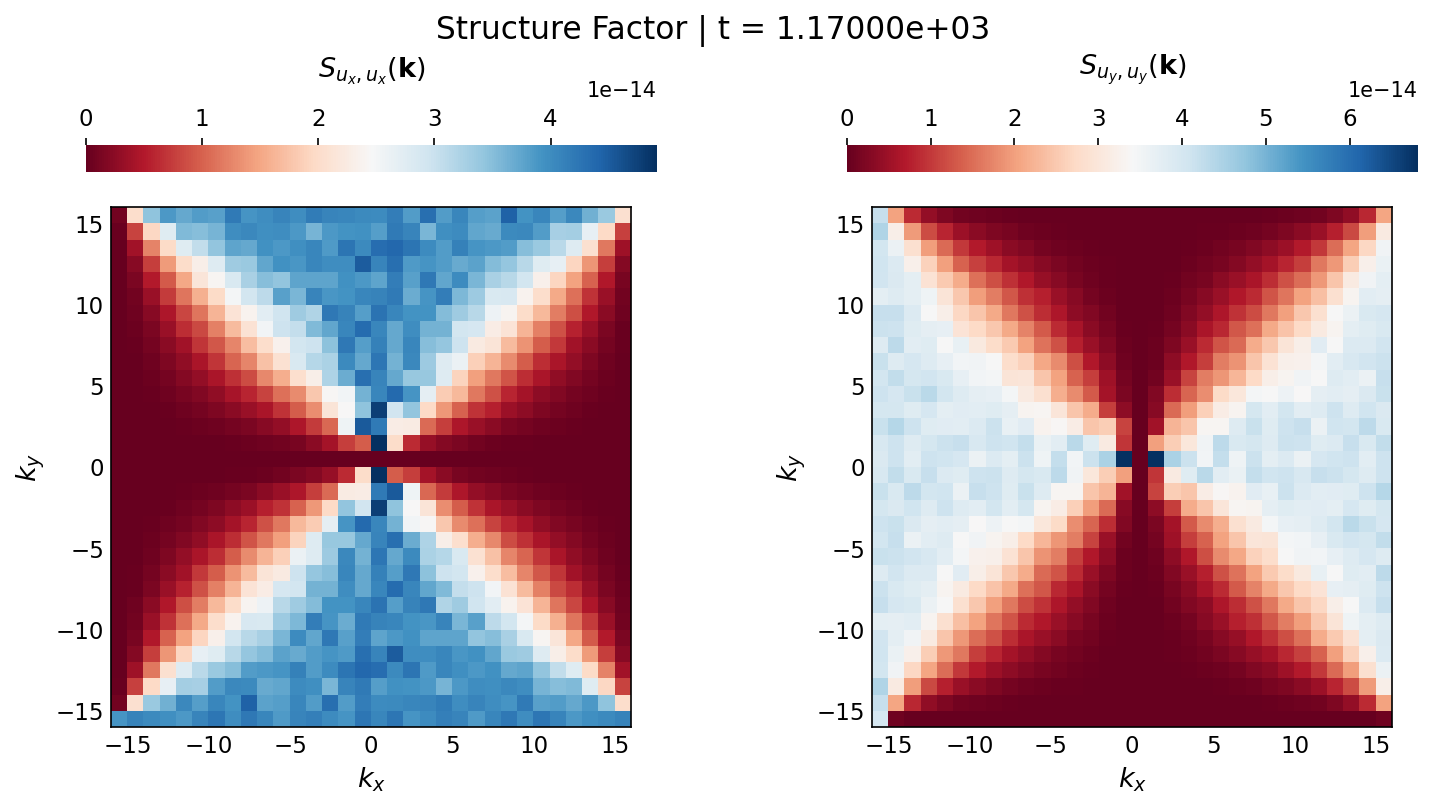

In [215]:
def structure_factor_helper(ax, data, title, cmap='RdBu', fontsize=13):
    """Plot structure factor data with colorbar on top in separated axes"""
    plot_height, plot_bottom = 0.75, 0.05
    cbar_height, cbar_bottom = 0.04, 0.85
    plot_width, plot_left = 0.90, 0.075  
    
    pbbox = transforms.Bbox.from_bounds(plot_left, plot_bottom, plot_width, plot_height)
    cbbox = transforms.Bbox.from_bounds(plot_left, cbar_bottom, plot_width, cbar_height)
    
    to_axes_bbox = transforms.BboxTransformTo(ax.get_position())
    paxes = ax.figure.add_axes(pbbox.transformed(to_axes_bbox))
    caxes = ax.figure.add_axes(cbbox.transformed(to_axes_bbox))
    ax.axis('off')
    
    Ny, Nx = data.shape
    extent = [-Nx/2, Nx/2, -Ny/2, Ny/2]  
    
    # vmax = np.max(np.abs(data))
    # im = paxes.imshow(data, cmap=cmap, origin='lower', extent=extent, aspect=1, 
    #                   norm=SymLogNorm(linthresh=1e-15, vmin=-vmax, vmax=vmax, base=10))

    vmax = data.max()
    # vmax = 3e-13
    # im = paxes.imshow(data, cmap=cmap, origin='lower', extent=extent, aspect=1, norm=LogNorm(vmin=1e-16, vmax=vmax))
    im = paxes.imshow(data, cmap=cmap, origin='lower', extent=extent, aspect=1, vmin=0, vmax=vmax)
    
    paxes.set_xlabel('$k_x$', fontsize=fontsize)
    paxes.set_ylabel('$k_y$', fontsize=fontsize)
    paxes.tick_params(length=0, width=0, labelsize=fontsize-2)
    
    caxes.text(0.5, 3.1, title, transform=caxes.transAxes, 
               ha='center', va='bottom', fontsize=fontsize)
    
    cbar = plt.colorbar(im, cax=caxes, orientation='horizontal')
    cbar.outline.set_visible(False)
    caxes.xaxis.set_ticks_position('top')
    cbar.ax.tick_params(labelsize=fontsize-2)
    
    return paxes, caxes


yt.funcs.mylog.setLevel(40)
Nx, Ny = first_ds.domain_dimensions[:2]
nrows, ncols = 1, 2
# cmap = 'magma'
# cmap = 'Blues'
cmap = 'RdBu'
for i in range(55, len(ts)):
    ds = ts[i]
    cg = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=[Nx, Ny, 1])
    
    S_xx = np.array(cg['struct_fact_velx_velx'][:, :, 0].v)
    S_yy = np.array(cg['struct_fact_vely_vely'][:, :, 0].v)
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 6), dpi=150)
    fig.suptitle(f'Structure Factor | t = {ds.current_time.v:.5e}', fontsize=15, y=0.94)
    
    structure_factor_helper(axes[0], S_xx.T, r'$S_{u_x, u_x}(\mathbf{k})$', cmap = cmap)
    structure_factor_helper(axes[1], S_yy.T, r'$S_{u_y, u_y}(\mathbf{k})$', cmap = cmap)
    
    plt.show()

In [221]:
def df_trace_f(ts):
    # Get domain dimensions
    Nx, Ny = ts[0].domain_dimensions[:2]
    
    # Initialize lists to store our data
    times = []
    traces = []
    
    
    # Loop over the time series
    for ds in ts:
        # Get the physical simulation time
        sim_time = ds.current_time.v
        
        # Extract the 2D arrays using covering_grid
        cg = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=[Nx, Ny, 1])
        S_xx = np.array(cg['struct_fact_velx_velx'][:, :, 0].v)
        S_yy = np.array(cg['struct_fact_vely_vely'][:, :, 0].v)
        
        # Calculate the trace (sum of diagonals)
        # We sum over the entire k-space array to get the total energy trace for this timestep
        trace_val = np.sum(S_xx + S_yy)
        
        # Append to lists
        times.append(sim_time)
        traces.append(trace_val)
    
    # Create the Pandas DataFrame
    df_trace = pd.DataFrame({
        'Time': times,
        'Trace': traces
    })

    return df_trace

# Display the first few rows
# print(df_trace)

df_trace_1 = df_trace_f(ts)
df_trace_2 = df_trace_f(ts_2)
df_trace_3 = df_trace_f(ts_3)

IndexError: list index out of range

In [217]:
kB = 1.380649e-16
T = 294.0
cell_depth = 3.5e-5  # 3.0e-9 # 1.0e-5
Nx, Ny = 32, 32
dx, dy = 1/Nx, 1/Ny
rho = 1

# answer = (kB * T) / (rho * dx * dy * cell_depth)
answer = (kB * T) / (rho)
print(answer)

4.05910806e-14


In [218]:
print(df_trace['Trace'] / np.square(Nx))

0     3.980572e-14
1     3.946812e-14
2     3.966973e-14
3     3.975163e-14
4     3.999019e-14
5     3.996189e-14
6     3.995418e-14
7     3.995637e-14
8     4.018717e-14
9     4.022415e-14
10    4.010271e-14
11    4.007480e-14
12    4.005971e-14
13    4.016897e-14
14    4.023465e-14
15    4.032055e-14
16    4.036747e-14
17    4.042789e-14
18    4.051595e-14
19    4.053607e-14
20    4.056768e-14
21    4.055891e-14
22    4.048973e-14
23    4.049142e-14
24    4.047555e-14
25    4.052885e-14
26    4.051419e-14
27    4.052908e-14
28    4.053366e-14
29    4.054556e-14
30    4.055182e-14
31    4.055318e-14
32    4.056231e-14
33    4.056536e-14
34    4.056795e-14
35    4.059431e-14
36    4.058893e-14
37    4.059736e-14
38    4.058455e-14
39    4.057512e-14
40    4.057476e-14
41    4.056433e-14
42    4.055003e-14
43    4.056343e-14
44    4.055498e-14
45    4.054799e-14
46    4.052345e-14
47    4.052387e-14
48    4.052050e-14
49    4.053540e-14
50    4.051906e-14
51    4.049369e-14
52    4.0468

NameError: name 'df_trace_3' is not defined

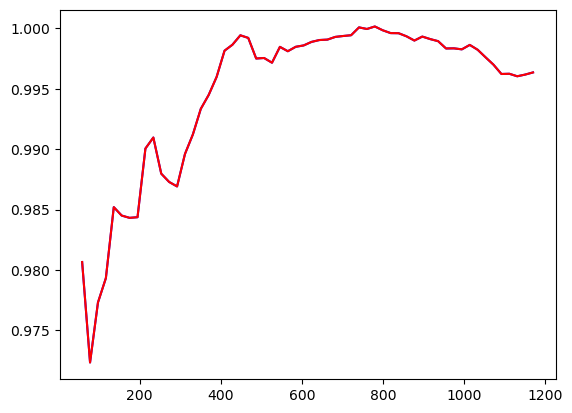

In [223]:
# plt.plot(df_trace['Time'], df_trace['Trace'] / np.square(Nx), c = "blue", label = r"$Tr(S_{u,u}) / N_x N_y$")
# plt.axhline(answer, label = r"$k_B \: T / \rho$", c = "black", ls = "--")
# plt.title(f'SF Trace $N_x$ = {Nx} and visc = 1e-4\n(incflo, use_tensor_solve = false, PPM_flux_limiter = False)')

plt.plot(df_trace_1['Time'], (df_trace_1['Trace'] / np.square(Nx)) / answer, c = "blue", label = r"$Tr(S_{u,u}) / N_x N_y$")
plt.plot(df_trace_2['Time'], (df_trace_2['Trace'] / np.square(Nx)) / answer, c = "red", label = r"$Tr(S_{u,u}) / N_x N_y$")
plt.plot(df_trace_3['Time'], (df_trace_3['Trace'] / np.square(Nx)) / answer, c = "gren", label = r"$Tr(S_{u,u}) / N_x N_y$")
plt.axhline(answer / answer, label = r"$k_B \: T / \rho$", c = "black", ls = "--")
plt.title(f'Normalized Trace $N_x$ = {Nx} and visc = 1e-4\n(incflo, use_tensor_solve = false, PPM_flux_limiter = False)')

# plt.ylim(bottom=3.65e-14)
plt.xlabel(r"$t$")
plt.legend()
plt.show()
plt.close()

In [209]:
# num_avg_steps = 10
# # recent_ts = ts[-num_avg_steps:]
# recent_ts = ts[33:43]

# # Initialize an empty 2D array to hold the averaged trace
# avg_trace_2d = np.zeros((Nx, Ny))

# count = 0
# for ds in recent_ts:
#     cg = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=[Nx, Ny, 1])
#     S_xx = np.array(cg['struct_fact_velx_velx'][:, :, 0].v)
#     S_yy = np.array(cg['struct_fact_vely_vely'][:, :, 0].v)
    
#     # Add the trace array for this timestep to the running total
#     avg_trace_2d += (S_xx + S_yy)
#     count += 1

# # Divide by the number of steps to get the average
# avg_trace_2d /= num_avg_steps
# # print(count)

ds_final = ts[-1]

# Extract the covering grid
cg = ds_final.covering_grid(level=0, left_edge=ds_final.domain_left_edge, dims=[Nx, Ny, 1])

# Extract S_xx and S_yy and sum them to get the Trace
S_xx = np.array(cg['struct_fact_velx_velx'][:, :, 0].v)
S_yy = np.array(cg['struct_fact_vely_vely'][:, :, 0].v)

trace_2d = S_xx + S_yy

# trace_2d = trace_2d / (Nx * Ny)

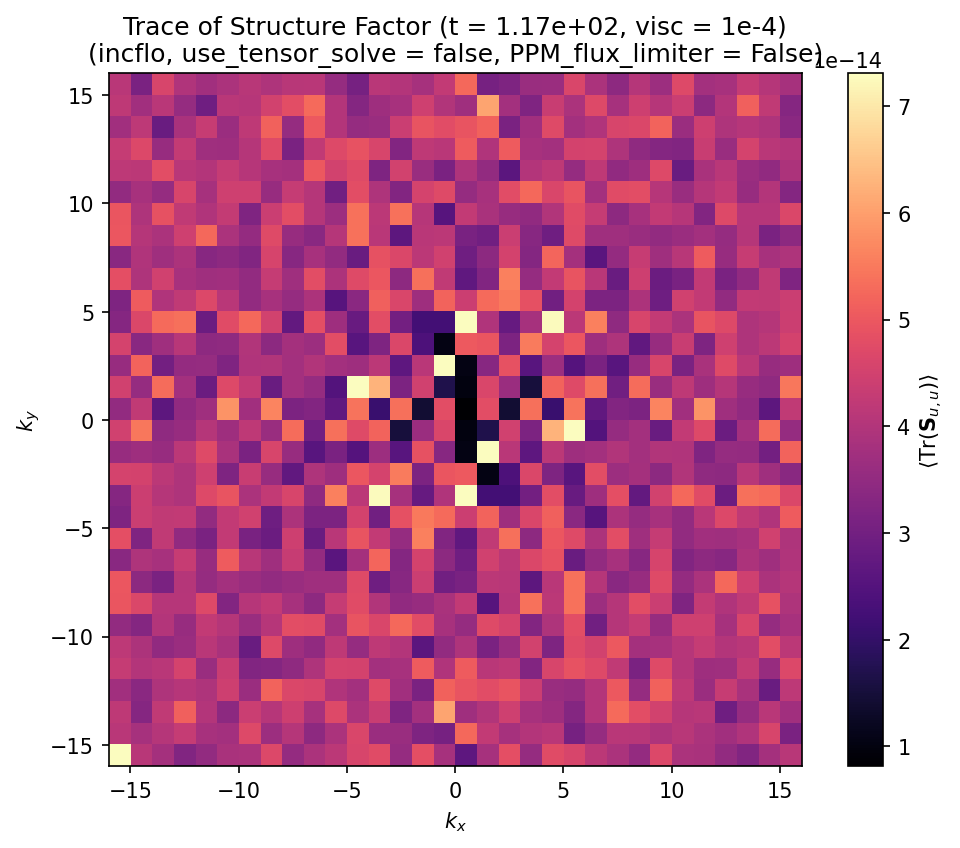

In [210]:
# Plot the 2D Trace as a function of the wave vector (kx, ky)
plt.figure(figsize=(8, 6), dpi=150)

# Set extent to match k-space (centered at 0)
extent = [-Nx/2, Nx/2, -Ny/2, Ny/2]
# vmin = 1e-18
# vmax = 3e-13
# vmax = 6e-14
# vmax = trace_2d.max()
vmin = .2 * answer
vmax = 1.8 * answer
# vmin = .8 * answer
# vmax = 1.2 * answer
im = plt.imshow(trace_2d.T, origin='lower', extent=extent, cmap='magma', vmin = vmin, vmax = vmax)
# im = plt.imshow(trace_2d.T, origin='lower', extent=extent, cmap='magma', 
#                 norm=LogNorm(vmin=vmin, vmax=vmax))

plt.colorbar(im, label=r'$\langle \text{Tr}(\mathbf{S}_{u,u}) \rangle$')
# start_time = recent_ts[0].current_time.v
# end_time = recent_ts[-1].current_time.v
time = ds_final.current_time.v

# plt.title(f'Averaged Trace of Structure Factor (incflo)\n(t = {start_time:.2e} to {end_time:.2e})')
plt.title(f'Trace of Structure Factor (t = {time:.2e}, visc = 1e-4)\n(incflo, use_tensor_solve = false, PPM_flux_limiter = False)')

# plt.title(f'Averaged Trace of Structure Factor (Last {num_avg_steps} steps)')
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')
plt.show()

In [211]:
vmax

7.306394508000001e-14

In [187]:
answer

4.05910806e-14

## Energy spectrum

In [188]:
files = sorted(glob.glob('turb_vel*.txt'))
dfs = []
for f in files:
    num = int(re.search(r'turb_vel(\d+)\.txt', f).group(1))
    df = pd.read_csv(f, sep='\s+', header=None)
    df['file_num'] = num
    dfs.append(df)

spect_data = pd.concat(dfs, ignore_index=True)

In [189]:
spect_data

,0,1,file_num
0,1,0.000000e+00,0
1,2,0.000000e+00,0
2,3,0.000000e+00,0
3,4,0.000000e+00,0
4,5,0.000000e+00,0
...,...,...,...
310,11,2.445476e-12,300000
311,12,3.826994e-12,300000
312,13,3.788088e-12,300000
313,14,2.961078e-12,300000


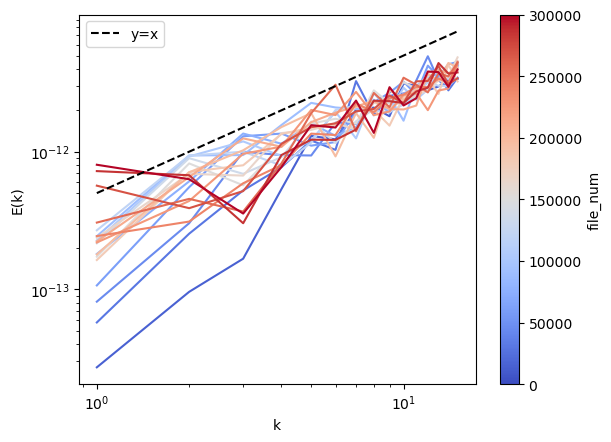

In [203]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots()
file_nums = sorted(spect_data['file_num'].unique())
# colors = cm.coolwarm(np.linspace(0, 1, len(file_nums)))
norm = mcolors.Normalize(vmin=min(file_nums), vmax=max(file_nums))
cmap = cm.coolwarm

# for color, (num, group) in zip(colors, spect_data.groupby('file_num')):
#     ax.plot(group[0], group[1], color=color, label=num)
for num, group in spect_data.groupby('file_num'):
    ax.plot(group[0], group[1], color=cmap(norm(num)))
    k_vals = group[0]
ax.set_xscale('log')
ax.set_yscale('log')

ax.plot(k_vals, 5e-13*k_vals, 'k--', label='y=x')
ax.set_xlabel('k')
ax.set_ylabel('E(k)')
# ax.legend(title='file_num', loc='lower right')
ax.legend()
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=ax, label='file_num')